# Article Recommendation System with Machine Learning
Recommendation engines power much of what we read and watch online. News sites, blogs, and platforms like Medium rely on them to keep readers engaged by suggesting relevant content. In this project, we’ll build a simple yet practical article recommender in Python, showing how machine learning can connect readers with articles they’re most likely to enjoy.

<div align="center">
<img src="https://www.popoptiq.com/wp-content/uploads/2018/08/articles-lead-image-082418-min.jpg" />
</div>

## Understanding Article Recommendation System
There are several approaches to recommendations. For articles, a content-based strategy works well because it focuses on what’s written rather than on historical user behavior. If someone is reading a post about clustering, we want to suggest other clustering-related articles that are semantically similar.

To recommend articles based on content, we will:

1. Represent each article’s text as a numerical vector
2. Compare that representation to all other articles in the catalog
3. Return the closest matches to the article currently being read

We’ll use [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) to measure how similar two article vectors are. It’s a common and effective technique for text similarity and forms the core of many content-based recommenders. In the next sections, we’ll implement this pipeline end to end in Python. You can download the dataset from [here](https://raw.githubusercontent.com/amankharwal/Website-data/master/articles.csv).

## 1. Importing Libraries
First, let’s import the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import neattext as ntx
from wordcloud import WordCloud
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings

### Configuration
Let’s configure the necessary settings.
- Ignore warnings for cleaner output.
- Set default figure size to 12x8 inches for plots.

In [21]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Data Loading
Next, we will read the dataset from the URL and take a quick look at its structure.

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/amankharwal/Website-data/master/articles.csv', encoding='ISO-8859-1')

In [4]:
df.head()

,Article,Title
0,Data analysis is the process of inspecting and...,Best Books to Learn Data Analysis
1,The performance of a machine learning algorith...,Assumptions of Machine Learning Algorithms
2,You must have seen the news divided into categ...,News Classification with Machine Learning
3,When there are only two classes in a classific...,Multiclass Classification Algorithms in Machin...
4,The Multinomial Naive Bayes is one of the vari...,Multinomial Naive Bayes in Machine Learning


In [5]:
df.shape

(34, 2)

In [6]:
df.isnull().sum()

Article    0
Title      0
dtype: int64

## 3. Data Preprocessing
Before building our recommendation system, we need to preprocess the data and clean the articles.

In [7]:
# Function to clean the text
def clean_text(text):
    text = text.lower()
    text = ntx.remove_stopwords(text)
    text = ntx.remove_multiple_spaces(text)
    text = ntx.normalize(text)
    return text

df.Article.apply(clean_text).head()

0    data analysis process inspecting exploring dat...
1    performance machine learning algorithm particu...
2    seen news divided categories news website. pop...
3    classes classification problem, problem binary...
4    multinomial naive bayes variants naive bayes a...
Name: Article, dtype: object

In [8]:
df['article_clean'] = df['Article'].apply(clean_text)

## 4. Visualization
Let's visualize the articles with WordCloud.

In [9]:
def generate_wordcloud(text, mask=None):
    if mask:
        mask = np.array(Image.open(f'../assets/{mask}.png'))
    wordcloud = WordCloud(
        width=800, height=400, 
        background_color='white',
        mask=mask,
    ).generate(text)
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [10]:
articles = " ".join(df.article_clean)

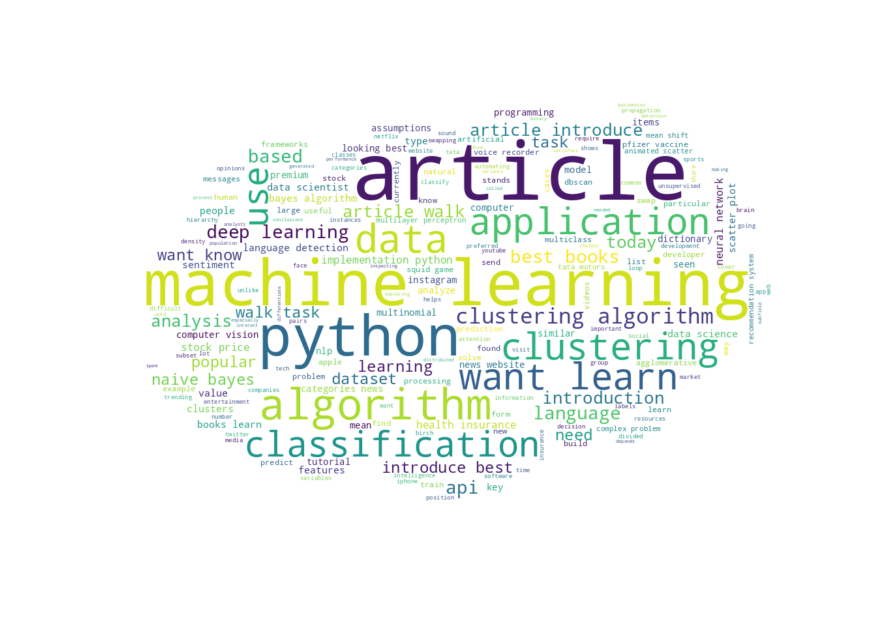

In [11]:
generate_wordcloud(articles, "cloud")

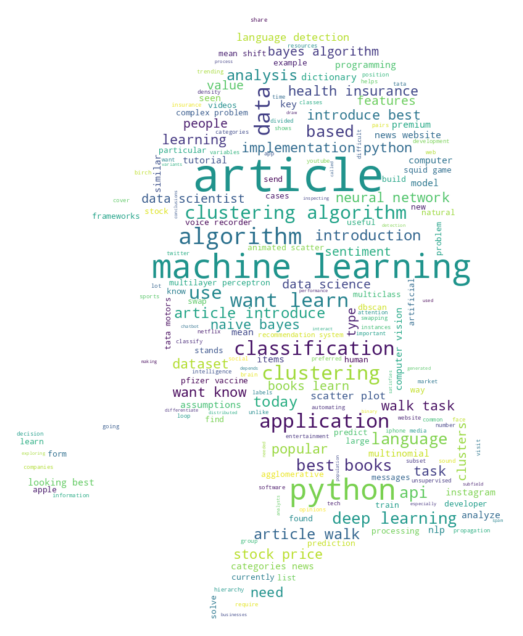

In [12]:
generate_wordcloud(articles, "sherlock")

## 5. Vectorization
Next, we will vectorize the articles.

In [13]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))

In [14]:
article_mat = vectorizer.fit_transform(df.article_clean)

In [15]:
article_mat.shape

(34, 1235)

## 6. Recommendation System

### Cosine Similarity
Cosine similarity is a measure of similarity between two vectors of an inner product space that measures the cosine of the angle between them. It is a common and effective technique for text similarity and forms the core of many content-based recommenders.

$ {\displaystyle {\text{cosine similarity}}=S_{C}(A,B):=\cos(\theta )={\mathbf {A} \cdot \mathbf {B}  \over \|\mathbf {A} \|\|\mathbf {B} \|}={\frac {\sum \limits _{i=1}^{n}{A_{i}B_{i}}}{{\sqrt {\sum \limits _{i=1}^{n}{A_{i}^{2}}}}\cdot {\sqrt {\sum \limits _{i=1}^{n}{B_{i}^{2}}}}}},} $

### Cosine Similarity Matrix
Now, we will calculate the cosine similarity matrix. It is a square matrix that contains the cosine similarity scores between all articles in the dataset. The diagonal elements of the matrix are 1, because the similarity of an article with itself is 1. Also, the similarity matrix is symmetric, because the similarity of article A with article B is the same as the similarity of article B with article A. There are some duplicate article titles in the dataset, so we will remove them.

In [16]:
similarity = cosine_similarity(article_mat)

In [17]:
# cosine similarity matrix as a dataframe
csm_df = pd.DataFrame(
    similarity,
    index=df.Title,
    columns=df.Title
)
csm_df.head()

Title,Best Books to Learn Data Analysis,Assumptions of Machine Learning Algorithms,News Classification with Machine Learning,Multiclass Classification Algorithms in Machine Learning,Multinomial Naive Bayes in Machine Learning,News Classification with Machine Learning,Best Books to Learn NLP,Send Instagram Messages using Python,Pfizer Vaccine Sentiment Analysis using Python,Squid Game Sentiment Analysis using Python,...,K-Means Clustering in Machine Learning,Animated Scatter Plot using Python,Tata Motors Stock Price Prediction with Machine Learning,Apple Stock Price Prediction with Machine Learning,Best Books to Learn Deep Learning,Applications of Deep Learning,Introduction to Recommendation Systems,Use Cases of Different Machine Learning Algorithms,Naive Bayes Algorithm in Machine Learning,Swap Items of a Python List
Title,,,,,,,,,,,,,,,,,,,,,
Best Books to Learn Data Analysis,1.000000,0.018149,0.021919,0.065672,0.020677,0.021919,0.108315,0.022118,0.080320,0.036069,...,0.002635,0.025543,0.023373,0.031626,0.159610,0.043643,0.061246,0.058966,0.002085,0.016173
Assumptions of Machine Learning Algorithms,0.018149,1.000000,0.062202,0.101098,0.098865,0.062202,0.023654,0.006868,0.025646,0.002176,...,0.088019,0.014273,0.026114,0.094645,0.152176,0.131087,0.000985,0.239435,0.177376,0.001920
News Classification with Machine Learning,0.021919,0.062202,1.000000,0.093842,0.033162,1.000000,0.015878,0.012986,0.041545,0.017676,...,0.032260,0.014117,0.047275,0.090513,0.069927,0.031214,0.031821,0.068630,0.034080,0.017771
Multiclass Classification Algorithms in Machine Learning,0.065672,0.101098,0.093842,1.000000,0.055875,0.093842,0.053079,0.008793,0.009508,0.009857,...,0.019661,0.010196,0.015836,0.046681,0.111377,0.077919,0.011884,0.131980,0.028919,0.014712
Multinomial Naive Bayes in Machine Learning,0.020677,0.098865,0.033162,0.055875,1.000000,0.033162,0.053274,0.007717,0.007084,0.007344,...,0.042180,0.016073,0.012022,0.039510,0.044909,0.030566,0.020525,0.078036,0.458596,0.011093


Here, we remove duplicated article titles by creating boolean masks that identify unique rows and columns (keeping the first occurrence), then filter the cosine similarity matrix accordingly.

In [18]:
# remove duplicated article titles
unique_row_mask = ~csm_df.index.duplicated(keep='first')
unique_column_mask = ~csm_df.columns.duplicated(keep='first')

csm_df = csm_df.loc[unique_row_mask, unique_column_mask]

Let's test the recommendation system.

In [19]:
test_title = df.Title.sample().values[0]
test_title

'Types of Neural Networks'

In [20]:
csm_df[test_title].sort_values(ascending=False).head(10)

Title
Types of Neural Networks                                    1.000000
Best Books to Learn Deep Learning                           0.230611
Multilayer Perceptron in Machine Learning                   0.173609
Applications of Deep Learning                               0.122340
Best Resources to Learn Python                              0.069457
Clustering Algorithms in Machine Learning                   0.057587
Use Cases of Different Machine Learning Algorithms          0.055081
Multiclass Classification Algorithms in Machine Learning    0.047795
Assumptions of Machine Learning Algorithms                  0.039413
Best Books to Learn Data Analysis                           0.038728
Name: Types of Neural Networks, dtype: float64

## 7. Conclusion
This notebook built a content-based article recommendation system using NLP: after
cleaning text, we vectorized articles with TF-IDF and computed cosine similarity
to retrieve the most similar articles.

**Key insights**
- Preprocessing (lowercasing, stopword removal) improved vector quality.
- TF-IDF with cosine similarity produced coherent, topic-aligned recommendations.
- Deduplicating titles (keeping first occurrence) ensured a well-formed, stable similarity matrix.
- Feature dimensionality and n-gram choices trade off recall, noise, and runtime.

**Future improvements**
- Incorporate semantic embeddings (e.g., Sentence-BERT) for deeper meaning matching.
- Blend content with behavioral data (hybrid recommender) for personalization.
- Scale retrieval with ANN indexes (e.g., FAISS) and add caching for latency.
- Add offline evaluation (precision@k, MRR) and online A/B testing.
- Expose a simple API/UI and schedule periodic model/data refreshes.